In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os
load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API Key is set.")
else:
    raise ValueError("Google API Key is not set.")

Google API Key is set.


In [2]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

### **LLM Pydantic Schema**

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

# Structured output schema used by the Router LLM.
# The LLM must return data in this exact format.
class llm_schema(BaseModel):

    # Restricts the category to one of the allowed values only.
    # The router will use this field to decide which node/workflow
    # should handle the request.
    #
    # Example outputs:
    # "insta"
    # "twitter"
    # "linkedin"
    category: Literal['insta', 'twitter', 'linkedin'] = Field(...,description="Category of the post to generate")

    # Stores the actual topic extracted from the user's request.
    #
    # Example:
    # "Generative AI"
    # "LangGraph"
    # "Software Engineering"
    topic: str = Field(...,description="Topic of the post to generate")

In [4]:
# Bind the Pydantic schema to the LLM.
# This forces the LLM to return output matching the llm_schema structure.
llm_with_schema = llm.with_structured_output(llm_schema)

# Invoke the LLM with the user request.
# The LLM returns an llm_schema object containing:
# - category (insta/twitter/linkedin)
# - topic
#
# Access only the category field from the structured output.
llm_with_schema.invoke("I want to generate a post for twitter about AI").category

'twitter'

### **State Schema**

In [5]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    
    input: str
    topic: str
    post: str
    category: str

In [6]:
def decider_node(state: graph_schema) -> graph_schema:

    # Retrieve the user's input from the graph state.
    # Example:
    # "Create a Twitter post about AI"
    user_input = state['input']

    # Pass the user input to the structured-output LLM.
    # The LLM analyzes the request and returns a Pydantic object
    # matching the llm_schema format.
    response = llm_with_schema.invoke(user_input)  # Pydantic Object

    # Extract the platform/category selected by the LLM.
    # Example:
    # "twitter"
    category = response.category

    # Extract the topic identified by the LLM.
    # Example:
    # "AI"
    topic = response.topic

    # Store the extracted category in the graph state.
    # This will later be used by the router/conditional edge
    # to decide which node should execute next.
    state['category'] = category

    # Store the extracted topic in the graph state.
    # Content-generation nodes will use this topic to create the post.
    state['topic'] = topic

    # Return the updated state so that downstream nodes
    # can access the category and topic.
    return state

def create_post_insta(state: graph_schema) -> graph_schema:

    # Retrieve the topic from the graph state.
    # This topic was previously extracted by the decider node.
    topic = state['topic']

    # Generate an Instagram-style post using the topic.
    # The prompt instructs the LLM to create content that is
    # casual, engaging, and suitable for Instagram.
    post = llm.invoke(f"Write an Instagram post about {topic}. Keep the tone casual and engaging.").content

    # Store the generated post in the graph state.
    # Other nodes (if any) can access it later.
    state['post'] = post

    # Return the output that should be added to the graph state.
    # LangGraph will merge this returned dictionary into the state.
    return {'post': post}


def create_post_twitter(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a Twitter post
    post = llm.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

    # Update the state with the generated post
    state['post'] = post

    return {'post' : post}


def create_post_linkedin(state: graph_schema) -> graph_schema:
    

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative.").content

    # Update the state with the generated post
    state['post'] = post

    return {'post' : post}

In [7]:
def condition(state: graph_schema) -> str:

    category = state['category']

    if category == 'insta':
        return 'create_insta'
    elif category == 'twitter':
        return 'create_twitter'
    elif category == 'linkedin':
        return 'create_linkedin'
    else:
        raise ValueError("Invalid category")

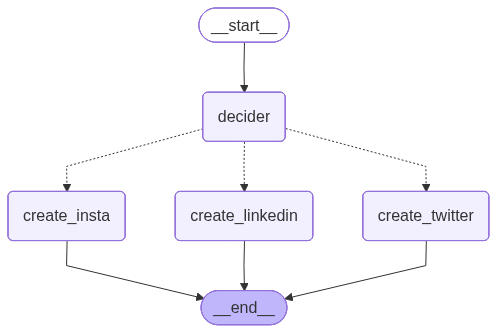

In [8]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider", decider_node)
graph.add_node("create_insta", create_post_insta)
graph.add_node("create_twitter", create_post_twitter)
graph.add_node("create_linkedin", create_post_linkedin)


graph.add_edge(START, "decider")
graph.add_conditional_edges("decider",condition,{
    'create_insta': "create_insta",
    'create_twitter': "create_twitter",
    'create_linkedin': "create_linkedin"
})

graph.add_edge("create_insta", END)
graph.add_edge("create_twitter", END)
graph.add_edge("create_linkedin", END) 


route_graph = graph.compile()


from IPython.display import Image, display

# You could see the errors with the below command
Image(route_graph.get_graph().draw_mermaid_png())

In [ ]:
route_graph.invoke({
    "input": "I want to generate a post for twitter about AI",
    "topic":"",
    "category":"",
    "post":""
})